# Dynamic IR-Drop Decomposition Analysis

This notebook analyzes dynamic IR-drop in a PDN netlist and decomposes the IR-drop at worst-case
instances into contributions from **"near"** instances (within a local window) and
**"far"** instances (outside the window).

This analysis helps identify whether IR-drop issues are caused by:
- **Local current density** (high near contribution)
- **Distributed grid resistance effects** (high far contribution)

## Overview

1. Load PDN netlist and create model
2. Run initial transient simulation to find worst instances
3. For each worst instance:
   - Define a spatial window around it
   - Partition current sources into "near" and "far"
   - Run decomposed transient simulations
   - Compute statistics
4. Visualize results

## Setup and Imports

In [1]:
import sys
import os
import time as time_module
from pathlib import Path
from typing import Any, Dict, List, Optional, Set, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Import project modules (installed via pip install -e .)
from parser.netlist import NetlistParser
from parser.current_sources import CurrentSource
from model.factory import create_model_from_pdn
from analysis.transient_solver import TransientIRDropSolver, IntegrationMethod
from graph.converter import detect_graph_type, ensure_rustworkx_graph

print("Imports successful!")

Imports successful!


## Configuration

Set the analysis parameters here:

In [2]:
# ==========================================
# CONFIGURATION - Modify these parameters
# ==========================================

# Netlist path
#NETLIST_DIR = Path('/wv/bwdev1/patrasej/dev/sigma_dvd/mpower_testcases/minion/db.sir/db/netlist')
NETLIST_DIR = Path('/home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled')

# Power net to analyze
NET_NAME = 'VDD_XLV'

# Time parameters
T_START = 0.0           # Start time (seconds)
T_END = 1e-9          # End time (seconds) - 1 ns
DT = 0.01e-9             # Time step (seconds) - 10 ps

# Analysis parameters
TOP_K = 2               # Number of worst instances to analyze
WINDOW_PERCENT = 10.0   # Window size as percentage of design dimensions
INTEGRATION_METHOD = 'be'  # 'trap' (Trapezoidal) or 'be' (Backward Euler)

# Optional: Pre-defined instances to analyze (set to None for auto-detection)
PREDEFINED_INSTANCES = None  # e.g., ['inst1', 'inst2'] or None

# Cache control
USE_CACHE = True        # Use cached pdn_graph.pkl if available

# Verbose output
VERBOSE = True

print("Configuration:")
print(f"  Netlist: {NETLIST_DIR}")
print(f"  Net: {NET_NAME}")
print(f"  Time: {T_START*1e9:.2f} ns to {T_END*1e9:.2f} ns, dt={DT*1e9:.3f} ns")
print(f"  Top-K: {TOP_K}")
print(f"  Window: {WINDOW_PERCENT}%")
print(f"  Integration: {INTEGRATION_METHOD}")

Configuration:
  Netlist: /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled
  Net: VDD_XLV
  Time: 0.00 ns to 1.00 ns, dt=0.010 ns
  Top-K: 2
  Window: 10.0%
  Integration: be


## Helper Functions

These functions handle location extraction, window computation, and source partitioning.

In [3]:
def parse_node_coordinates(node_name: str) -> Tuple[Optional[float], Optional[float]]:
    """Extract (x, y) coordinates from node name.
    
    Node name format: <x>_<y>_<layer> (e.g., "1000_2000_M1")
    """
    parts = str(node_name).split('_')
    if len(parts) >= 2:
        try:
            x = float(parts[0])
            y = float(parts[1])
            return (x, y)
        except ValueError:
            pass
    return (None, None)


def extract_instance_locations(
    current_sources: Dict[str, Any],
) -> Tuple[Dict[str, Tuple[float, float]], Tuple[float, float, float, float]]:
    """Extract (x, y) for each current source instance.
    
    Returns:
        Tuple of:
        - instance_coords: Dict mapping source name to (x, y) tuple
        - grid_bounds: (x_min, x_max, y_min, y_max) bounding box
    """
    instance_coords: Dict[str, Tuple[float, float]] = {}

    for name, src in current_sources.items():
        x, y = None, None

        # Try to get from InstanceInfo
        if hasattr(src, 'info') and src.info is not None:
            tile_x = getattr(src.info, 'tile_x', None)
            tile_y = getattr(src.info, 'tile_y', None)
            if tile_x and tile_y:
                x, y = tile_x, tile_y

        # Fall back to parsing node name
        if x is None or y is None:
            node = getattr(src, 'node1', None)
            if node:
                x, y = parse_node_coordinates(node)

        if x is not None and y is not None:
            instance_coords[name] = (float(x), float(y))

    # Compute grid bounds
    if instance_coords:
        xs = [c[0] for c in instance_coords.values()]
        ys = [c[1] for c in instance_coords.values()]
        grid_bounds = (min(xs), max(xs), min(ys), max(ys))
    else:
        grid_bounds = (0.0, 1.0, 0.0, 1.0)

    return instance_coords, grid_bounds


def compute_window_for_instance(
    center_x: float,
    center_y: float,
    grid_bounds: Tuple[float, float, float, float],
    window_percent: float,
) -> Tuple[float, float, float, float]:
    """Compute rectangular window centered at instance."""
    x_min_g, x_max_g, y_min_g, y_max_g = grid_bounds
    width = (x_max_g - x_min_g) * window_percent / 100.0
    height = (y_max_g - y_min_g) * window_percent / 100.0

    return (
        max(x_min_g, center_x - width / 2),
        min(x_max_g, center_x + width / 2),
        max(y_min_g, center_y - height / 2),
        min(y_max_g, center_y + height / 2),
    )


def windows_intersect(
    w1: Tuple[float, float, float, float],
    w2: Tuple[float, float, float, float],
) -> bool:
    """Check if two windows overlap."""
    return not (w1[1] < w2[0] or w2[1] < w1[0] or
                w1[3] < w2[2] or w2[3] < w1[2])


def partition_sources_by_window(
    current_sources: Dict[str, Any],
    instance_coords: Dict[str, Tuple[float, float]],
    window_bounds: Tuple[float, float, float, float],
) -> Tuple[Set[str], Set[str]]:
    """Split sources into near (inside) and far (outside) window."""
    x_min, x_max, y_min, y_max = window_bounds
    near: Set[str] = set()
    far: Set[str] = set()

    for name in current_sources:
        if name not in instance_coords:
            continue
        x, y = instance_coords[name]
        if x_min <= x <= x_max and y_min <= y <= y_max:
            near.add(name)
        else:
            far.add(name)

    return near, far


print("Helper functions defined.")

Helper functions defined.


In [4]:
def find_worst_instances_spatially_separated(
    peak_ir_drop_per_node: Dict[Any, float],
    current_sources: Dict[str, Any],
    instance_coords: Dict[str, Tuple[float, float]],
    grid_bounds: Tuple[float, float, float, float],
    top_k: int,
    window_percent: float,
) -> List[Tuple[str, str, float, float, float]]:
    """Find top-K worst instances with non-overlapping windows.
    
    Uses greedy selection: picks worst instance, then next worst whose
    window doesn't overlap with any already-selected window.
    
    Returns:
        List of (instance_name, node, x, y, peak_ir_drop) tuples.
    """
    # Build mapping from node to instance
    node_to_instance: Dict[str, str] = {}
    for name, src in current_sources.items():
        node = getattr(src, 'node1', None)
        if node:
            node_to_instance[node] = name

    # Build candidates list
    candidates: List[Tuple[str, str, float, float, float]] = []
    for node, ir_drop in peak_ir_drop_per_node.items():
        inst = node_to_instance.get(node)
        if inst and inst in instance_coords:
            x, y = instance_coords[inst]
            candidates.append((inst, node, x, y, ir_drop))

    # Sort by IR-drop descending
    candidates.sort(key=lambda c: c[4], reverse=True)

    # Greedily select non-overlapping instances
    selected: List[Tuple[str, str, float, float, float]] = []
    selected_windows: List[Tuple[float, float, float, float]] = []

    for inst, node, x, y, ir_drop in candidates:
        if len(selected) >= top_k:
            break

        window = compute_window_for_instance(x, y, grid_bounds, window_percent)
        overlaps = any(windows_intersect(window, w) for w in selected_windows)

        if not overlaps:
            selected.append((inst, node, x, y, ir_drop))
            selected_windows.append(window)

    return selected


print("Worst instance selection function defined.")

Worst instance selection function defined.


## Load PDN Netlist

In [5]:
import pickle
import types

# Pickle compatibility shims: map old module paths to new locations
# so that pickle files created with the old 'core' / 'pdn_parser' / 'src.' layout can load
def _install_pickle_compat():
    """Register sys.modules aliases for old module paths."""
    from graph import rx_graph as _rx_graph
    from graph import converter as _converter
    from parser import current_sources as _cs

    # core.graph_converter -> graph.rx_graph (has RustworkxMultiDiGraphWrapper)
    core_pkg = types.ModuleType('core')
    core_pkg.graph_converter = _rx_graph
    sys.modules.setdefault('core', core_pkg)
    sys.modules.setdefault('core.graph_converter', _rx_graph)

    # pdn_parser -> parser.current_sources (has CurrentSource)
    pdn_parser_mod = types.ModuleType('pdn_parser')
    pdn_parser_mod.CurrentSource = _cs.CurrentSource
    # Also copy any other names pickle might need
    for attr in ('Pulse', 'PWL', 'InstanceInfo'):
        if hasattr(_cs, attr):
            setattr(pdn_parser_mod, attr, getattr(_cs, attr))
    sys.modules.setdefault('pdn_parser', pdn_parser_mod)

_install_pickle_compat()


class _SrcPrefixUnpickler(pickle.Unpickler):
    """Unpickler that strips 'src.' prefix from module paths.

    Handles pickle files created when packages lived under src/ and were
    imported as src.graph.rx_graph, src.parser.current_sources, etc.
    """
    def find_class(self, module: str, name: str):
        if module.startswith('src.'):
            module = module[4:]  # strip 'src.' prefix
        return super().find_class(module, name)


timings = {}
t0 = time_module.perf_counter()

pkl_path = NETLIST_DIR / 'pdn_graph.pkl'

if USE_CACHE and pkl_path.exists():
    print(f"Loading cached graph from {pkl_path}...")
    with open(pkl_path, 'rb') as f:
        graph = _SrcPrefixUnpickler(f).load()
    
    # Detect and convert if needed
    graph_type = detect_graph_type(graph)
    print(f"  Graph type: {graph_type}")
    
    if graph_type == 'networkx':
        print("  Converting NetworkX graph to Rustworkx format...")
        graph = ensure_rustworkx_graph(graph, verbose=False)
        print("  Conversion complete!")
else:
    print(f"Parsing netlist: {NETLIST_DIR}")
    parser = NetlistParser(str(NETLIST_DIR))
    graph = parser.parse()

timings['parse'] = time_module.perf_counter() - t0

print(f"\nGraph loaded in {timings['parse']:.2f}s")
print(f"  Nodes: {graph.number_of_nodes()}")
print(f"  Edges: {graph.number_of_edges()}")

Loading cached graph from /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled/pdn_graph.pkl...
  Graph type: rustworkx

Graph loaded in 4.16s
  Nodes: 136035
  Edges: 483835


## Create Model and Extract Current Sources

In [6]:
# Create model
t0 = time_module.perf_counter()
model = create_model_from_pdn(graph, NET_NAME)
timings['model'] = time_module.perf_counter() - t0

print(f"Model created in {timings['model']:.3f}s")
print(f"  Vdd: {model.vdd} V")
print(f"  Nodes: {model.graph.number_of_nodes()}")
print(f"  Pad nodes: {len(model.pad_nodes)}")

# Get current sources
graph_dict = None
if hasattr(graph, 'graph') and isinstance(graph.graph, dict):
    graph_dict = graph.graph
elif hasattr(graph, '_attrs'):
    graph_dict = graph._attrs

if graph_dict is None:
    raise RuntimeError("Cannot access graph metadata")

# Try raw objects first, then fall back to serialized
current_sources_all = graph_dict.get('_instance_sources_objects', {})
if not current_sources_all:
    serialized = graph_dict.get('instance_sources', {})
    current_sources_all = {k: CurrentSource.from_dict(v) for k, v in serialized.items()}

# Filter to only sources belonging to the target net (whose node1 is in the model)
node_to_idx = model.edge_cache.node_to_idx
current_sources = {
    name: src for name, src in current_sources_all.items()
    if getattr(src, 'node1', None) in node_to_idx
}

print(f"\nFound {len(current_sources)} current sources for net {NET_NAME} "
      f"(out of {len(current_sources_all)} total)")

/wv/bwdev1/patrasej/dev/sigma_dvd/prototype/.trees/transient-plot/src/model/unified_model.py:301: UserWarning: Removed 4 floating island(s) with 434 nodes (not connected to any voltage source). Total components: 5, kept: 1
  warnings.warn(


Model created in 1.665s
  Vdd: 0.66 V
  Nodes: 136035
  Pad nodes: 1

Found 60000 current sources for net VDD_XLV (out of 60000 total)


Extracted 60000 instance locations in 0.179s
Grid bounds: X=[989000, 2268790], Y=[1046400, 2428800]


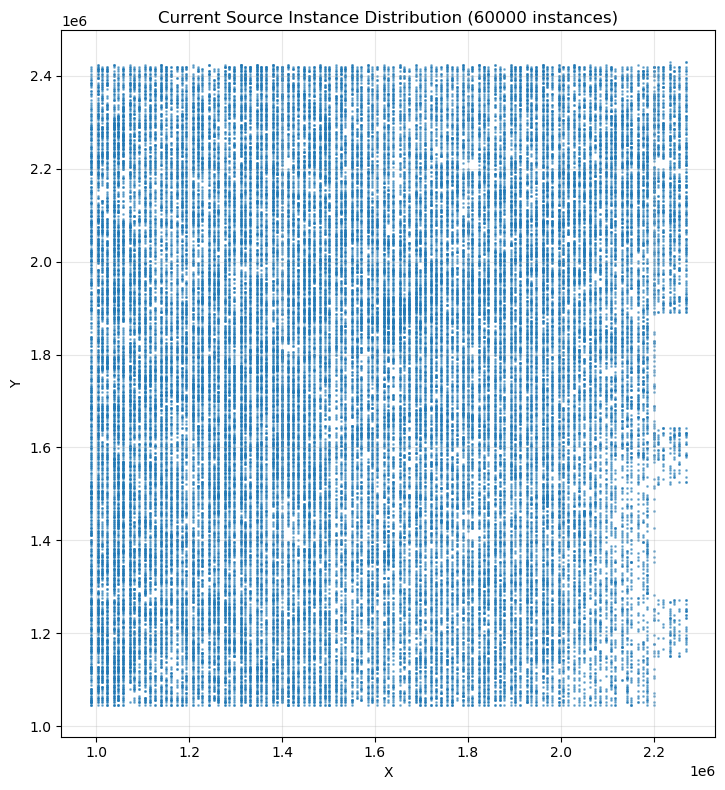

In [7]:
%matplotlib inline
# Extract instance locations
t0 = time_module.perf_counter()
instance_coords, grid_bounds = extract_instance_locations(current_sources)
timings['extract_locations'] = time_module.perf_counter() - t0

print(f"Extracted {len(instance_coords)} instance locations in {timings['extract_locations']:.3f}s")
print(f"Grid bounds: X=[{grid_bounds[0]:.0f}, {grid_bounds[1]:.0f}], Y=[{grid_bounds[2]:.0f}, {grid_bounds[3]:.0f}]")

# Visualize instance distribution
fig, ax = plt.subplots(figsize=(10, 8))
xs = [c[0] for c in instance_coords.values()]
ys = [c[1] for c in instance_coords.values()]
ax.scatter(xs, ys, alpha=0.5, s=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'Current Source Instance Distribution ({len(instance_coords)} instances)')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
from solver.unified_solver import HAS_CHOLMOD, set_use_cholmod, get_use_cholmod, get_active_backend, set_cholmod_mode, set_cholmod_ordering
print(f'HAS_CHOLMOD: {HAS_CHOLMOD}')
print(f'get_use_cholmod(): {get_use_cholmod()}')
print(f'get_active_backend(): {get_active_backend()}')
set_cholmod_mode('simplicial')
set_cholmod_ordering('amd')

# set_use_cholmod(True)
# print(f'After set_use_cholmod(True): backend={get_active_backend()}')

HAS_CHOLMOD: True
get_use_cholmod(): None
get_active_backend(): cholmod


## Create Transient Solver

In [9]:
# Create solver (use vectorize_threshold=0 to enable solve_transient_multi_rhs)
solver = TransientIRDropSolver(model, graph, vectorize_threshold=0)

# Build source name list and index mapping
source_names = list(current_sources.keys())
name_to_idx = {name: i for i, name in enumerate(source_names)}
n_sources = len(source_names)

print(f"Transient solver created")
print(f"  Number of sources: {n_sources}")

Transient solver created
  Number of sources: 60000


## Find Worst Instances

Run initial transient simulation to identify the instances with highest peak IR-drop.

In [10]:
if PREDEFINED_INSTANCES is not None:
    print(f"Using {len(PREDEFINED_INSTANCES)} pre-defined instances")
    # TODO: Resolve predefined instances
    worst_instances = []  # Placeholder
else:
    print("Running initial transient analysis to find worst instances...")
    t0 = time_module.perf_counter()

    # Create mask for all sources
    mask_all = np.ones(n_sources, dtype=bool)

    # Get all source nodes for tracking
    all_source_nodes = list(set(
        getattr(current_sources[name], 'node1', None)
        for name in source_names
        if getattr(current_sources[name], 'node1', None) is not None
    ))

    # Limit tracked nodes to avoid memory issues
    max_track = min(10, len(all_source_nodes))
    track_nodes_initial = all_source_nodes[:max_track]

    method_enum = IntegrationMethod.TRAPEZOIDAL if INTEGRATION_METHOD == 'trap' else IntegrationMethod.BACKWARD_EULER

    # Run single-mask solve
    results = solver.solve_transient_multi_rhs(
        t_start=T_START,
        t_end=T_END,
        dt=DT,
        source_masks=mask_all[np.newaxis, :],
        method=method_enum,
        track_nodes=track_nodes_initial,
        verbose=VERBOSE,
    )
    initial_result = results[0]

    timings['initial_transient'] = time_module.perf_counter() - t0

    # Find worst instances with spatial separation
    worst_instances = find_worst_instances_spatially_separated(
        initial_result.peak_ir_drop_per_node,
        current_sources,
        instance_coords,
        grid_bounds,
        TOP_K,
        WINDOW_PERCENT,
    )

    print(f"\nInitial transient completed in {timings['initial_transient']:.2f}s")
    print(f"Found {len(worst_instances)} spatially-separated worst instances:")
    for i, (inst, node, x, y, ir_drop) in enumerate(worst_instances, 1):
        print(f"  {i}. {inst[:50]}... @ ({x:.0f}, {y:.0f}): {ir_drop*1000:.3f} mV")

Running initial transient analysis to find worst instances...


Matrix factorization (cholmod(mode=simplicial, ordering=amd, idx=auto)): CSC conversion 13.28 ms, factorization 433.30 ms
Multi-RHS transient: 1 masks, 101 time steps
  Time step 0/101 (t=0.00 ns)
  Time step 10/101 (t=0.10 ns)
  Time step 20/101 (t=0.20 ns)
  Time step 30/101 (t=0.30 ns)
  Time step 40/101 (t=0.40 ns)
  Time step 50/101 (t=0.50 ns)
  Time step 60/101 (t=0.60 ns)
  Time step 70/101 (t=0.70 ns)
  Time step 80/101 (t=0.80 ns)
  Time step 90/101 (t=0.90 ns)
  Time step 100/101 (t=1.00 ns)

Initial transient completed in 6.95s
Found 2 spatially-separated worst instances:
  1. i_Inst037447:VDD_XLV:VDD:0:0:0:0:0... @ (1912400, 2256000): 47.842 mV
  2. i_Inst011524:VDD_XLV:VDD:0:0:0:0:0... @ (1467800, 1843200): 34.717 mV


## Near/Far Decomposition Analysis

For each worst instance, partition sources into "near" and "far" based on spatial window,
then run separate transient simulations.

In [11]:
from dataclasses import dataclass

@dataclass
class InstanceDecomposition:
    """Decomposition results for a single worst instance."""
    instance_name: str
    node: str
    x: float
    y: float
    window_bounds: Tuple[float, float, float, float]
    n_near_sources: int
    n_far_sources: int
    t_array: np.ndarray
    ir_drop_total: np.ndarray
    ir_drop_near: np.ndarray
    ir_drop_far: np.ndarray
    peak_total_mV: float
    peak_near_mV: float
    peak_far_mV: float
    peak_time_ns: float
    avg_total_mV: float
    avg_near_mV: float
    avg_far_mV: float
    near_fraction_at_peak: float
    far_fraction_at_peak: float
    avg_near_fraction: float
    avg_far_fraction: float


def compute_decomposition_stats(
    inst_name: str,
    node: str,
    x: float,
    y: float,
    window: Tuple[float, float, float, float],
    result_full: Any,
    result_near: Any,
    result_far: Any,
    n_near: int,
    n_far: int,
) -> InstanceDecomposition:
    """Compute decomposition statistics from transient results."""
    t_array = result_full.t_array

    # Get waveforms for the tracked node
    ir_total = result_full.get_ir_drop_waveform(node)
    ir_near = result_near.get_ir_drop_waveform(node)
    ir_far = result_far.get_ir_drop_waveform(node)

    # Peak statistics
    peak_total = np.max(ir_total)
    peak_near = np.max(ir_near)
    peak_far = np.max(ir_far)
    peak_idx = np.argmax(ir_total)
    peak_time = t_array[peak_idx]

    # Average statistics
    avg_total = np.mean(ir_total)
    avg_near = np.mean(ir_near)
    avg_far = np.mean(ir_far)

    # Fraction at peak
    total_at_peak = ir_total[peak_idx]
    if total_at_peak > 0:
        near_frac_peak = ir_near[peak_idx] / total_at_peak * 100
        far_frac_peak = ir_far[peak_idx] / total_at_peak * 100
    else:
        near_frac_peak = 0.0
        far_frac_peak = 0.0

    # Average fraction over time
    safe_total = np.where(ir_total > 1e-15, ir_total, 1e-15)
    near_frac_arr = ir_near / safe_total * 100
    far_frac_arr = ir_far / safe_total * 100
    avg_near_frac = np.mean(near_frac_arr)
    avg_far_frac = np.mean(far_frac_arr)

    return InstanceDecomposition(
        instance_name=inst_name,
        node=node,
        x=x,
        y=y,
        window_bounds=window,
        n_near_sources=n_near,
        n_far_sources=n_far,
        t_array=t_array,
        ir_drop_total=ir_total,
        ir_drop_near=ir_near,
        ir_drop_far=ir_far,
        peak_total_mV=peak_total * 1000,
        peak_near_mV=peak_near * 1000,
        peak_far_mV=peak_far * 1000,
        peak_time_ns=peak_time * 1e9,
        avg_total_mV=avg_total * 1000,
        avg_near_mV=avg_near * 1000,
        avg_far_mV=avg_far * 1000,
        near_fraction_at_peak=near_frac_peak,
        far_fraction_at_peak=far_frac_peak,
        avg_near_fraction=avg_near_frac,
        avg_far_fraction=avg_far_frac,
    )

print("Decomposition dataclass and helper defined.")

Decomposition dataclass and helper defined.


In [12]:
# Run decomposition analysis for each worst instance
decompositions: List[InstanceDecomposition] = []
t0_decomp = time_module.perf_counter()

method_enum = IntegrationMethod.TRAPEZOIDAL if INTEGRATION_METHOD == 'trap' else IntegrationMethod.BACKWARD_EULER

for rank, (inst_name, node, x, y, _) in enumerate(worst_instances, 1):
    print(f"\nAnalyzing instance {rank}/{len(worst_instances)}: {inst_name[:50]}...")

    window = compute_window_for_instance(x, y, grid_bounds, WINDOW_PERCENT)
    near_names, far_names = partition_sources_by_window(
        current_sources, instance_coords, window
    )

    print(f"  Window: [{window[0]:.0f}-{window[1]:.0f}] x [{window[2]:.0f}-{window[3]:.0f}]")
    print(f"  Near sources: {len(near_names)}, Far sources: {len(far_names)}")

    # Build boolean masks
    mask_all = np.ones(n_sources, dtype=bool)
    mask_near = np.array([name in near_names for name in source_names], dtype=bool)
    mask_far = np.array([name in far_names for name in source_names], dtype=bool)

    source_masks = np.stack([mask_all, mask_near, mask_far])  # (3, n_sources)

    # Run multi-RHS transient
    results = solver.solve_transient_multi_rhs(
        t_start=T_START,
        t_end=T_END,
        dt=DT,
        source_masks=source_masks,
        method=method_enum,
        track_nodes=[node],
        verbose=False,
    )
    result_full, result_near, result_far = results

    # Compute statistics
    decomp = compute_decomposition_stats(
        inst_name, node, x, y, window,
        result_full, result_near, result_far,
        len(near_names), len(far_names),
    )
    decompositions.append(decomp)
    
    print(f"  Peak IR-drop: {decomp.peak_total_mV:.3f} mV = {decomp.peak_near_mV:.3f} (near) + {decomp.peak_far_mV:.3f} (far)")
    print(f"  Near contribution: {decomp.near_fraction_at_peak:.1f}%")

timings['decomposition'] = time_module.perf_counter() - t0_decomp
print(f"\nDecomposition analysis completed in {timings['decomposition']:.2f}s")


Analyzing instance 1/2: i_Inst037447:VDD_XLV:VDD:0:0:0:0:0...
  Window: [1848410-1976390] x [2186880-2325120]
  Near sources: 545, Far sources: 59455
  Peak IR-drop: 47.842 mV = 35.177 (near) + 12.666 (far)
  Near contribution: 73.5%

Analyzing instance 2/2: i_Inst011524:VDD_XLV:VDD:0:0:0:0:0...
  Window: [1403810-1531790] x [1774080-1912320]
  Near sources: 707, Far sources: 59293
  Peak IR-drop: 34.717 mV = 31.660 (near) + 3.057 (far)
  Near contribution: 91.2%

Decomposition analysis completed in 10.16s


## Results Summary

In [13]:
print("=" * 80)
print("DYNAMIC IR-DROP DECOMPOSITION ANALYSIS RESULTS")
print("=" * 80)
print(f"Netlist: {NETLIST_DIR}")
print(f"Net: {NET_NAME}")
print(f"Method: transient ({INTEGRATION_METHOD.upper()})")
print(f"Time range: {T_START*1e9:.2f} ns - {T_END*1e9:.2f} ns (dt={DT*1e9:.2f} ns)")
print(f"Window size: {WINDOW_PERCENT:.1f}% of design")
print(f"Grid bounds: ({grid_bounds[0]:.0f}, {grid_bounds[1]:.0f}) x "
      f"({grid_bounds[2]:.0f}, {grid_bounds[3]:.0f})")
print()

print(f"TOP-{len(decompositions)} WORST INSTANCES WITH NEAR/FAR DECOMPOSITION")
print("=" * 80)
print(f"{'Rank':<5} {'Instance':<30} {'Peak(mV)':<10} {'Near(mV)':<10} {'Far(mV)':<10} {'Near%':<7} {'Far%':<7}")
print("-" * 80)

for i, inst in enumerate(decompositions, 1):
    inst_short = inst.instance_name[:28] + ".." if len(inst.instance_name) > 30 else inst.instance_name
    print(f"{i:<5} {inst_short:<30} {inst.peak_total_mV:<10.3f} {inst.peak_near_mV:<10.3f} "
          f"{inst.peak_far_mV:<10.3f} {inst.near_fraction_at_peak:<7.1f} {inst.far_fraction_at_peak:<7.1f}")

print()
if decompositions:
    avg_near_pct = np.mean([inst.near_fraction_at_peak for inst in decompositions])
    avg_far_pct = np.mean([inst.far_fraction_at_peak for inst in decompositions])
    print(f"Average near contribution: {avg_near_pct:.1f}%")
    print(f"Average far contribution: {avg_far_pct:.1f}%")

print()
print("Timing breakdown:")
for key, val in timings.items():
    print(f"  {key}: {val:.3f} s")

DYNAMIC IR-DROP DECOMPOSITION ANALYSIS RESULTS
Netlist: /home/patrasej/workspace_dev1/dev/sigma_dvd/prototype/netlist/netlist_sampled
Net: VDD_XLV
Method: transient (BE)
Time range: 0.00 ns - 1.00 ns (dt=0.01 ns)
Window size: 10.0% of design
Grid bounds: (989000, 2268790) x (1046400, 2428800)

TOP-2 WORST INSTANCES WITH NEAR/FAR DECOMPOSITION
Rank  Instance                       Peak(mV)   Near(mV)   Far(mV)    Near%   Far%   
--------------------------------------------------------------------------------
1     i_Inst037447:VDD_XLV:VDD:0:0.. 47.842     35.177     12.666     73.5    26.5   
2     i_Inst011524:VDD_XLV:VDD:0:0.. 34.717     31.660     3.057      91.2    8.8    

Average near contribution: 82.4%
Average far contribution: 17.6%

Timing breakdown:
  parse: 4.160 s
  model: 1.665 s
  extract_locations: 0.179 s
  initial_transient: 6.949 s
  decomposition: 10.165 s


## Visualization

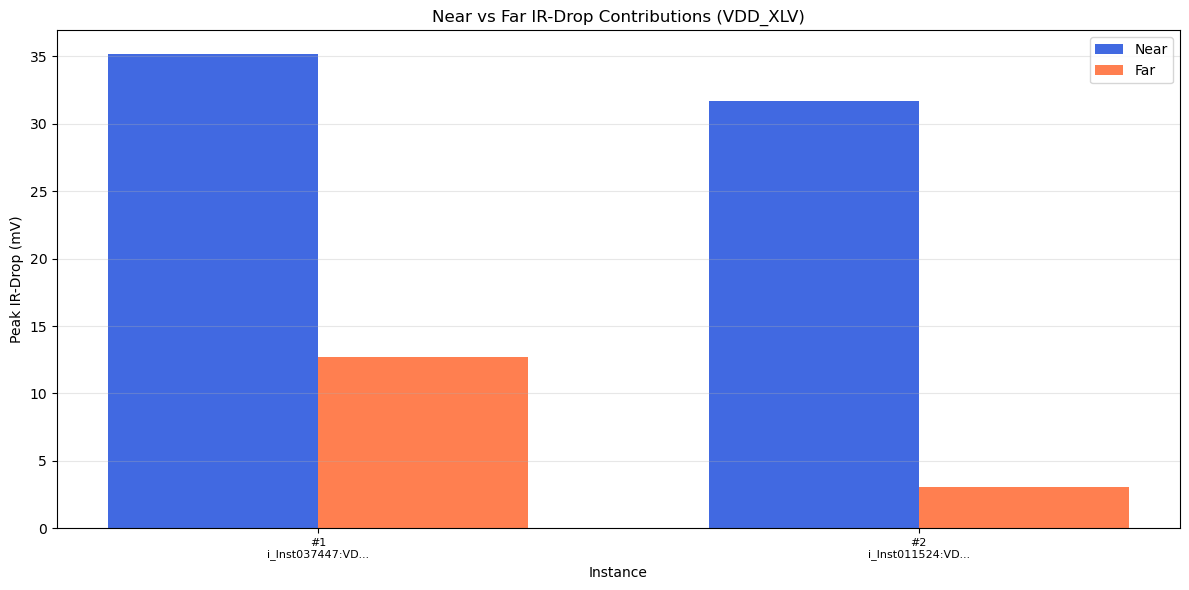

In [14]:
# 1. Bar chart: Near vs Far contributions
fig, ax = plt.subplots(figsize=(12, 6))
n_inst = len(decompositions)
x = np.arange(n_inst)
width = 0.35

near_drops = [inst.peak_near_mV for inst in decompositions]
far_drops = [inst.peak_far_mV for inst in decompositions]
labels = [f"#{i+1}\n{inst.instance_name[:15]}..." if len(inst.instance_name) > 15
          else f"#{i+1}\n{inst.instance_name}"
          for i, inst in enumerate(decompositions)]

bars_near = ax.bar(x - width/2, near_drops, width, label='Near', color='royalblue')
bars_far = ax.bar(x + width/2, far_drops, width, label='Far', color='coral')

ax.set_xlabel('Instance')
ax.set_ylabel('Peak IR-Drop (mV)')
ax.set_title(f'Near vs Far IR-Drop Contributions ({NET_NAME})')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

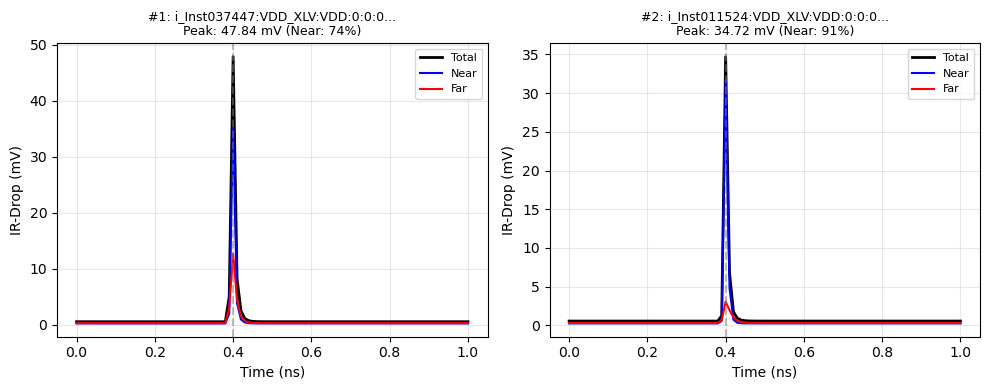

In [15]:
# 2. Waveform plots for each instance
n_cols = min(3, len(decompositions))
n_rows = (len(decompositions) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

for i, inst in enumerate(decompositions):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    
    t_ns = inst.t_array * 1e9
    ax.plot(t_ns, inst.ir_drop_total * 1000, 'k-', linewidth=2, label='Total')
    ax.plot(t_ns, inst.ir_drop_near * 1000, 'b-', linewidth=1.5, label='Near')
    ax.plot(t_ns, inst.ir_drop_far * 1000, 'r-', linewidth=1.5, label='Far')
    ax.axvline(inst.peak_time_ns, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('IR-Drop (mV)')
    ax.set_title(f'#{i+1}: {inst.instance_name[:30]}...\n'
                 f'Peak: {inst.peak_total_mV:.2f} mV (Near: {inst.near_fraction_at_peak:.0f}%)',
                 fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

# Hide empty subplots
for i in range(len(decompositions), n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

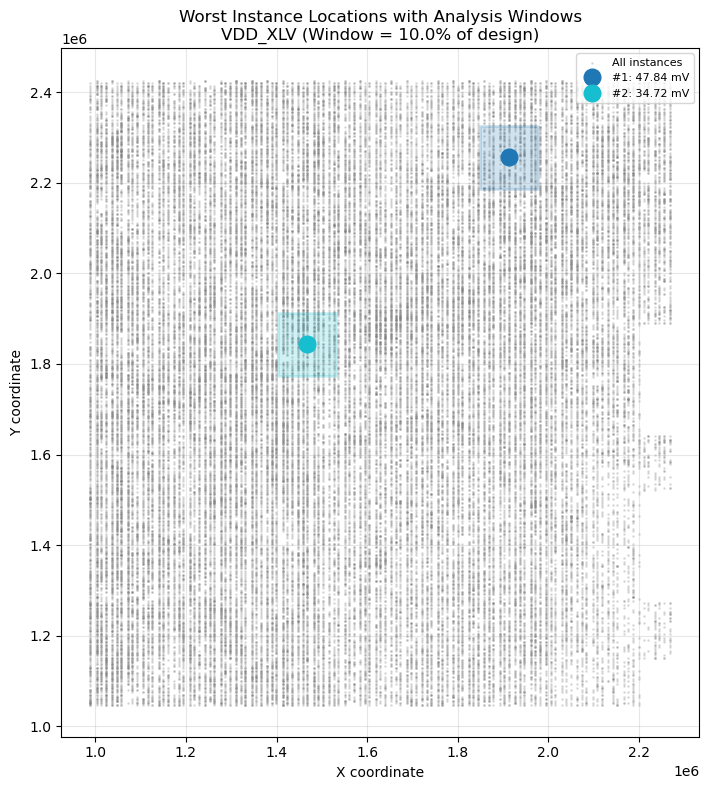

In [16]:
# 3. Spatial map with analysis windows
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all instances as background
xs_all = [c[0] for c in instance_coords.values()]
ys_all = [c[1] for c in instance_coords.values()]
ax.scatter(xs_all, ys_all, alpha=0.2, s=1, c='gray', label='All instances')

# Draw analysis windows and worst instance locations
colors = plt.cm.tab10(np.linspace(0, 1, len(decompositions)))
for i, inst in enumerate(decompositions):
    wx_min, wx_max, wy_min, wy_max = inst.window_bounds
    rect = patches.Rectangle(
        (wx_min, wy_min), wx_max - wx_min, wy_max - wy_min,
        linewidth=2, edgecolor=colors[i], facecolor=colors[i], alpha=0.2
    )
    ax.add_patch(rect)
    
    # Mark instance location
    ax.plot(inst.x, inst.y, 'o', markersize=12, color=colors[i],
            label=f'#{i+1}: {inst.peak_total_mV:.2f} mV')

x_min, x_max, y_min, y_max = grid_bounds
ax.set_xlim(x_min - (x_max - x_min) * 0.05, x_max + (x_max - x_min) * 0.05)
ax.set_ylim(y_min - (y_max - y_min) * 0.05, y_max + (y_max - y_min) * 0.05)

ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Worst Instance Locations with Analysis Windows\n{NET_NAME} (Window = {WINDOW_PERCENT}% of design)')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

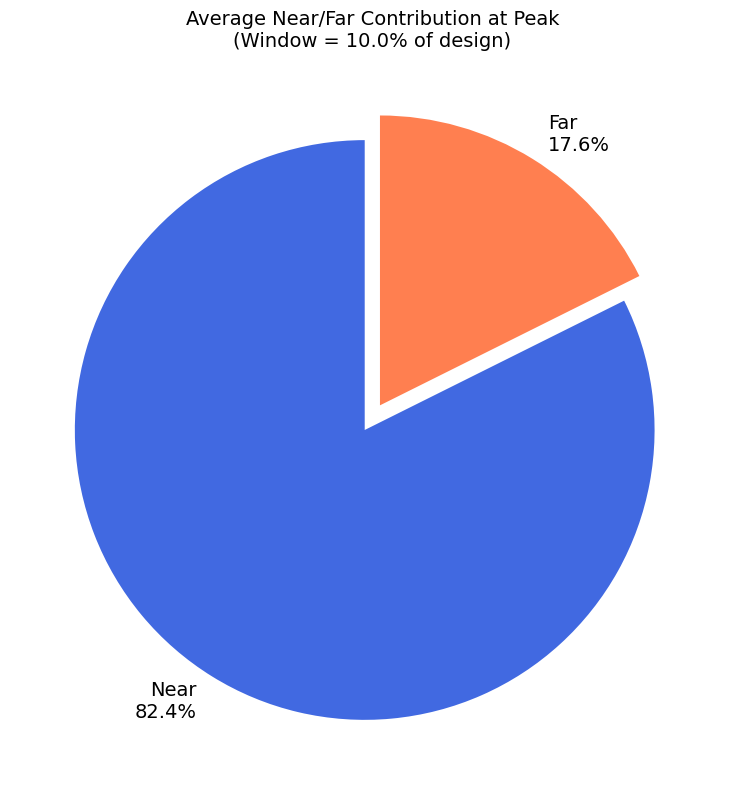

In [17]:
# 4. Pie chart: Average near/far breakdown
fig, ax = plt.subplots(figsize=(8, 8))

avg_near = np.mean([inst.near_fraction_at_peak for inst in decompositions])
avg_far = np.mean([inst.far_fraction_at_peak for inst in decompositions])

sizes = [avg_near, avg_far]
labels = [f'Near\n{avg_near:.1f}%', f'Far\n{avg_far:.1f}%']
colors_pie = ['royalblue', 'coral']
explode = (0.05, 0.05)

ax.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
       autopct='', startangle=90, textprops={'fontsize': 14})
ax.set_title(f'Average Near/Far Contribution at Peak\n(Window = {WINDOW_PERCENT}% of design)', fontsize=14)

plt.tight_layout()
plt.show()

## Adjoint Sensitivity Analysis

For each of the top-2 worst instances, identify the **top 10 aggressor** current sources
that contribute most to the IR-drop using adjoint sensitivity.

Two methods are compared:
- **Static adjoint** (`analyze_victim_static`): Uses steady-state sensitivity G⁻¹.
  Appropriate when RC time constants are much smaller than the time scale of interest.
- **Dynamic adjoint** (`analyze_victim`): Propagates sensitivities backward through the
  RC network's memory, capturing true time-varying attribution.

In [ ]:
from analysis.adjoint_sensitivity import AdjointSensitivitySolver

# Create adjoint solver from the existing transient solver (reuses RC system + LU)
adjoint_solver = AdjointSensitivitySolver.from_transient_solver(solver)

# Adjoint analysis parameters
ADJOINT_TOP_K = 10
ADJOINT_MEMORY_WINDOW = 20  # Number of time steps to look back

print(f"Adjoint solver created (reusing transient solver's RC system)")
print(f"  Top-K: {ADJOINT_TOP_K}")
print(f"  Memory window: {ADJOINT_MEMORY_WINDOW} steps")
print(f"  dt: {DT*1e9:.3f} ns")

In [ ]:
# Run static and dynamic adjoint for each worst instance
from dataclasses import dataclass as _dc
from analysis.adjoint_sensitivity import AdjointAttribution

@_dc
class AdjointComparison:
    """Holds static and dynamic adjoint results for one victim."""
    instance_name: str
    node: str
    x: float
    y: float
    static_result: AdjointAttribution
    dynamic_result: AdjointAttribution

adjoint_comparisons: List[AdjointComparison] = []

for rank, (inst_name, node, x, y, peak_ir) in enumerate(worst_instances, 1):
    print(f"\n{'='*70}")
    print(f"Instance #{rank}: {inst_name[:60]}")
    print(f"  Node: {node}, Location: ({x:.0f}, {y:.0f})")
    print(f"  Peak IR-drop (from transient): {peak_ir*1000:.3f} mV")

    # Use the peak time from the decomposition analysis
    observation_time = decompositions[rank - 1].peak_time_ns * 1e-9

    print(f"  Observation time: {observation_time*1e9:.3f} ns")

    # --- Static adjoint ---
    print(f"\n  Running static adjoint...")
    t0 = time_module.perf_counter()
    static_attr = adjoint_solver.analyze_victim_static(
        victim_node=node,
        observation_time=observation_time,
        top_k=ADJOINT_TOP_K,
        include_waveforms=False,
    )
    t_static = time_module.perf_counter() - t0
    print(f"    Done in {t_static:.2f}s")
    print(f"    IR-drop at T: {static_attr.ir_drop_at_T:.3f} mV")
    print(f"    Self-contribution: {static_attr.self_contribution_mV:.3f} mV "
          f"({static_attr.self_contribution_pct:.1f}%)")
    print(f"    Attribution efficiency: {static_attr.attribution_efficiency:.4f}")

    # --- Dynamic adjoint ---
    print(f"\n  Running dynamic adjoint (memory_window={ADJOINT_MEMORY_WINDOW})...")
    t0 = time_module.perf_counter()
    dynamic_attr = adjoint_solver.analyze_victim(
        victim_node=node,
        observation_time=observation_time,
        memory_window=ADJOINT_MEMORY_WINDOW,
        dt=DT,
        top_k=ADJOINT_TOP_K,
        include_waveforms=True,
    )
    t_dynamic = time_module.perf_counter() - t0
    print(f"    Done in {t_dynamic:.2f}s")
    print(f"    IR-drop at T: {dynamic_attr.ir_drop_at_T:.3f} mV")
    print(f"    Self-contribution: {dynamic_attr.self_contribution_mV:.3f} mV "
          f"({dynamic_attr.self_contribution_pct:.1f}%)")
    print(f"    Attribution efficiency: {dynamic_attr.attribution_efficiency:.4f}")

    adjoint_comparisons.append(AdjointComparison(
        instance_name=inst_name,
        node=node, x=x, y=y,
        static_result=static_attr,
        dynamic_result=dynamic_attr,
    ))

print(f"\n{'='*70}")
print(f"Adjoint analysis complete for {len(adjoint_comparisons)} instances.")

In [ ]:
# Print detailed comparison tables
for comp in adjoint_comparisons:
    s = comp.static_result
    d = comp.dynamic_result

    print(f"\n{'='*90}")
    print(f"ADJOINT COMPARISON: {comp.instance_name[:60]}")
    print(f"  Victim node: {comp.node}   Location: ({comp.x:.0f}, {comp.y:.0f})")
    print(f"{'='*90}")

    # Summary row
    print(f"\n  {'Metric':<30} {'Static':>15} {'Dynamic':>15} {'Diff':>12}")
    print(f"  {'-'*72}")
    print(f"  {'IR-drop at T (mV)':<30} {s.ir_drop_at_T:>15.3f} {d.ir_drop_at_T:>15.3f} "
          f"{d.ir_drop_at_T - s.ir_drop_at_T:>+12.3f}")
    print(f"  {'Self-contribution (mV)':<30} {s.self_contribution_mV:>15.3f} {d.self_contribution_mV:>15.3f} "
          f"{d.self_contribution_mV - s.self_contribution_mV:>+12.3f}")
    print(f"  {'Self-contribution (%)':<30} {s.self_contribution_pct:>15.1f} {d.self_contribution_pct:>15.1f}")
    print(f"  {'Attribution efficiency':<30} {s.attribution_efficiency:>15.4f} {d.attribution_efficiency:>15.4f}")
    print(f"  {'Total attributed (mV)':<30} {s.total_attributed_ir_drop:>15.3f} {d.total_attributed_ir_drop:>15.3f}")

    # Top aggressors side by side
    print(f"\n  TOP-{ADJOINT_TOP_K} AGGRESSORS")
    print(f"  {'Rank':<5} {'Static Node':<25} {'mV':>8} {'%':>6}   {'Dynamic Node':<25} {'mV':>8} {'%':>6}")
    print(f"  {'-'*90}")

    n_rows = max(len(s.top_aggressors), len(d.top_aggressors))
    for i in range(n_rows):
        # Static column
        if i < len(s.top_aggressors):
            sa = s.top_aggressors[i]
            s_node = str(sa.node)[:23]
            s_mv = f"{sa.contribution_mV:.3f}"
            s_pct = f"{sa.contribution_pct:.1f}"
        else:
            s_node, s_mv, s_pct = "", "", ""

        # Dynamic column
        if i < len(d.top_aggressors):
            da = d.top_aggressors[i]
            d_node = str(da.node)[:23]
            d_mv = f"{da.contribution_mV:.3f}"
            d_pct = f"{da.contribution_pct:.1f}"
        else:
            d_node, d_mv, d_pct = "", "", ""

        print(f"  {i+1:<5} {s_node:<25} {s_mv:>8} {s_pct:>6}   {d_node:<25} {d_mv:>8} {d_pct:>6}")

    # Check overlap in top-K sets
    s_nodes = {a.node for a in s.top_aggressors}
    d_nodes = {a.node for a in d.top_aggressors}
    overlap = s_nodes & d_nodes
    print(f"\n  Overlap in top-{ADJOINT_TOP_K}: {len(overlap)}/{ADJOINT_TOP_K} nodes in common")

In [ ]:
# Visualization: Side-by-side bar charts of top-K aggressors (static vs dynamic)
n_victims = len(adjoint_comparisons)
fig, axes = plt.subplots(n_victims, 2, figsize=(16, 5 * n_victims), sharey='row')
if n_victims == 1:
    axes = axes.reshape(1, -1)

for vi, comp in enumerate(adjoint_comparisons):
    for ci, (label, attr, color) in enumerate([
        ('Static', comp.static_result, 'steelblue'),
        ('Dynamic', comp.dynamic_result, 'darkorange'),
    ]):
        ax = axes[vi, ci]
        aggressors = attr.top_aggressors[:ADJOINT_TOP_K]
        nodes = [str(a.node)[-15:] for a in aggressors]  # last 15 chars
        contribs = [a.contribution_mV for a in aggressors]

        y_pos = np.arange(len(aggressors))
        ax.barh(y_pos, contribs, color=color, alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(nodes, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('Contribution (mV)')
        ax.set_title(
            f'{label} Adjoint — #{vi+1} {comp.instance_name[:25]}...\n'
            f'IR-drop: {attr.ir_drop_at_T:.2f} mV, '
            f'Self: {attr.self_contribution_mV:.2f} mV ({attr.self_contribution_pct:.0f}%)',
            fontsize=9,
        )
        ax.grid(axis='x', alpha=0.3)

        # Add self-contribution marker
        if attr.self_contribution_mV > 0:
            ax.axvline(attr.self_contribution_mV, color='red', linestyle='--',
                       alpha=0.6, label=f'Self: {attr.self_contribution_mV:.2f} mV')
            ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Spatial map: aggressor locations for each victim
fig, axes = plt.subplots(1, n_victims, figsize=(8 * n_victims, 7))
if n_victims == 1:
    axes = [axes]

for vi, comp in enumerate(adjoint_comparisons):
    ax = axes[vi]

    # Background: all instances in gray
    ax.scatter(xs_all, ys_all, alpha=0.1, s=1, c='gray')

    # Plot top aggressor locations for both methods
    for label, attr, marker, color in [
        ('Static', comp.static_result, 'o', 'steelblue'),
        ('Dynamic', comp.dynamic_result, '^', 'darkorange'),
    ]:
        agg_xs, agg_ys, agg_sizes = [], [], []
        for agg in attr.top_aggressors[:ADJOINT_TOP_K]:
            coords = instance_coords.get(
                next((sn for sn in agg.source_names if sn in instance_coords), None)
            )
            if coords is None:
                # Fall back to parsing coordinates from the node name
                coords_parsed = parse_node_coordinates(agg.node)
                if coords_parsed[0] is not None:
                    coords = coords_parsed
            if coords is not None:
                agg_xs.append(coords[0])
                agg_ys.append(coords[1])
                agg_sizes.append(max(20, abs(agg.contribution_mV) * 50))

        ax.scatter(agg_xs, agg_ys, s=agg_sizes, marker=marker, color=color,
                   edgecolors='black', linewidths=0.5, alpha=0.8, label=f'{label} top-{ADJOINT_TOP_K}')

    # Mark victim
    ax.plot(comp.x, comp.y, '*', markersize=18, color='red', markeredgecolor='black',
            markeredgewidth=1, label='Victim', zorder=10)

    # Draw decomposition window
    decomp = decompositions[vi]
    wx_min, wx_max, wy_min, wy_max = decomp.window_bounds
    rect = patches.Rectangle(
        (wx_min, wy_min), wx_max - wx_min, wy_max - wy_min,
        linewidth=1.5, edgecolor='green', facecolor='none', linestyle='--', label='Near window',
    )
    ax.add_patch(rect)

    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title(
        f'#{vi+1} Aggressor Locations\n{comp.instance_name[:35]}...\n'
        f'IR-drop: {comp.static_result.ir_drop_at_T:.2f} mV',
        fontsize=9,
    )
    ax.legend(loc='upper right', fontsize=7)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Static vs Dynamic Adjoint: Interpretation

- **Static adjoint** uses the steady-state sensitivity matrix G⁻¹. It answers: *"If this source were always on, how much would it affect the victim?"* Fast (single solve) but ignores RC time constants.

- **Dynamic adjoint** propagates sensitivities backward through the RC network's memory window. It answers: *"Given the actual time-varying currents, which sources contributed most to the IR-drop at time T?"*

**When the results agree** (same top aggressors, similar contributions): the RC time constants are small relative to the current switching — the grid responds quasi-statically.

**When results differ**: decoupling capacitance plays a significant role. Sources that switch near time T may rank higher in the dynamic analysis, while DC-heavy sources rank higher in static.

## Export Results (Optional)

In [18]:
import json

# Export results to JSON
output_data = {
    'netlist_dir': str(NETLIST_DIR),
    'net_name': NET_NAME,
    'method': 'transient',
    'integration_method': INTEGRATION_METHOD,
    't_start_ns': T_START * 1e9,
    't_end_ns': T_END * 1e9,
    'dt_ns': DT * 1e9,
    'window_percent': WINDOW_PERCENT,
    'grid_bounds': list(grid_bounds),
    'timings': timings,
    'worst_instances': [
        {
            'instance_name': inst.instance_name,
            'node': inst.node,
            'location': [inst.x, inst.y],
            'window_bounds': list(inst.window_bounds),
            'n_near_sources': inst.n_near_sources,
            'n_far_sources': inst.n_far_sources,
            'peak_ir_drop': {
                'total_mV': inst.peak_total_mV,
                'near_mV': inst.peak_near_mV,
                'far_mV': inst.peak_far_mV,
            },
            'peak_time_ns': inst.peak_time_ns,
            'near_fraction_at_peak_percent': inst.near_fraction_at_peak,
            'far_fraction_at_peak_percent': inst.far_fraction_at_peak,
        }
        for inst in decompositions
    ],
}

# Uncomment to save
# output_path = project_root / 'results' / 'dynamic_irdrop_decomposition.json'
# with open(output_path, 'w') as f:
#     json.dump(output_data, f, indent=2)
# print(f"Results saved to: {output_path}")

print("Results data prepared (uncomment above to save to file)")

Results data prepared (uncomment above to save to file)


## Interpretation Guide

### Near vs Far Contribution Analysis

- **High Near Contribution (>70%)**: IR-drop is dominated by local current density. 
  - Consider adding more local decap or improving local power grid routing.
  
- **High Far Contribution (>50%)**: IR-drop is significantly affected by distributed loads.
  - Consider improving global power grid impedance (wider straps, more vias).
  - Check for insufficient power pad distribution.

- **Balanced Contribution**: Both local and distributed effects contribute.
  - May need both local and global improvements.

### Window Size Selection

- **Smaller window (5-10%)**: Captures immediate local effects. Good for identifying hotspots.
- **Larger window (15-25%)**: Includes broader neighborhood. Better for understanding regional effects.

### Key Metrics

- **Peak IR-Drop**: Maximum voltage drop at the instance
- **Near Fraction at Peak**: Percentage of peak IR-drop from near sources at the time of maximum total IR-drop
- **Average Fraction**: Time-averaged contribution (useful for steady-state analysis)